# Week 3 — Exploratory Data Analysis for Bike Rental Prediction

## Introduction

In Week 2, the primary focus of the project was building a reproducible preprocessing pipeline for the bike rental dataset. Multiple operational and contextual data sources were combined, cleaned, transformed, and organized into a structured dataset suitable for later machine learning workflows.

The goal of this notebook is to explore and better understand the prepared dataset before training regression models for bike rental demand prediction.

Exploratory Data Analysis (EDA) is an important step in every machine learning project because it helps uncover patterns, relationships, inconsistencies, and potential modeling challenges within the data. Before selecting models or optimizing performance, it is essential to understand how the target variable behaves, how features interact with each other, and whether the dataset contains data quality issues that may affect later predictions.

This analysis focuses on:

* understanding temporal bike rental demand patterns,
* analyzing relationships between rental activity and external factors such as weather and holidays,
* identifying possible data quality issues and outliers,
* exploring correlations between features and the target variable,
* and developing initial ideas for feature engineering and model validation strategies.

The findings from this notebook will serve as the foundation for the regression modeling and machine learning experiments implemented in the later stages of Week 3.

---

## Imports and Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")

In [3]:
DATASET_PATH = Path("../../data/processed/bike_rental_features.csv")

df = pd.read_csv(DATASET_PATH)

---

## 2. Dataset Overview

This section provides an initial overview of the prepared bike rental dataset before moving into deeper exploratory analysis and regression modeling.

The dataset combines:

* hourly bike rental activity,
* weather information,
* temporal features,
* and holiday indicators.

Each row represents the rental activity  during a specific hourly time window.

The primary target variable for later machine learning workflows is:

* `total_rentals`



### 2.1 Dataset Structure

The dataset structure is first inspected to verify that the preprocessing pipeline produced the expected output and to better understand the available features.


In [4]:
df.head()

,datetime_hour,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,hour,weekday,month,is_weekend,is_holiday,booked_rentals,direct_pickups,total_rentals
0,2011-01-01 00:00:00,clear,3.3,3.0,81.0,0.0,0,5,1,True,False,13,3,16
1,2011-01-01 01:00:00,clear,2.3,2.0,80.0,0.0,1,5,1,True,False,32,8,40
2,2011-01-01 02:00:00,clear,2.3,2.0,80.0,0.0,2,5,1,True,False,27,5,32
3,2011-01-01 03:00:00,clear,3.3,3.0,75.0,0.0,3,5,1,True,False,10,3,13
4,2011-01-01 04:00:00,clear,3.3,3.0,75.0,0.0,4,5,1,True,False,1,0,1


In [5]:
df.shape

(17379, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   datetime_hour            17379 non-null  str    
 1   conditions               17379 non-null  str    
 2   temperature_c            17379 non-null  float64
 3   perceived_temperature_c  17379 non-null  float64
 4   humidity                 17379 non-null  float64
 5   windspeed_kmh            17379 non-null  float64
 6   hour                     17379 non-null  int64  
 7   weekday                  17379 non-null  int64  
 8   month                    17379 non-null  int64  
 9   is_weekend               17379 non-null  bool   
 10  is_holiday               17379 non-null  bool   
 11  booked_rentals           17379 non-null  int64  
 12  direct_pickups           17379 non-null  int64  
 13  total_rentals            17379 non-null  int64  
dtypes: bool(2), float64(4), int64(6),

#### Observations

* The prepared dataset contains 17378 hourly rental records with 14 columns.

* The dataset combines temporal, weather, operational, and calendar-related information.

* Most features already use appropriate data types for analysis. `datetime_hour` are currently stored as strings and may need to be converted or excluded depending on the later analysis and modeling step.

* The `conditions` column is stored as a string and represents a categorical weather feature that will require encoding before it can be used efficiently in machine learning models.

* All columns are complete, indicating that the preprocessing pipeline produced a consistent forecasting dataset without missing operational or weather observations.

* The dataset size and memory usage remain manageable for experimentation and model training within pandas and scikit-learn workflows.


### 2.2 Summary Statistics

Summary statistics are inspected to better understand the distributions and ranges of the numerical features within the dataset.

This step helps identify potential anomalies, extreme values, unusual feature ranges, and general characteristics of the rental and weather-related variables before moving into deeper analysis.


In [7]:
df.describe()

,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,hour,weekday,month,booked_rentals,direct_pickups,total_rentals
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,15.354203,15.437016,62.845043,12.736233,11.546752,3.011451,6.537775,153.786869,35.676218,189.463088
std,9.049874,11.335074,19.200855,8.196891,6.914405,2.001966,3.438776,151.357286,49.305030,181.387599
min,-7.100000,-16.000000,8.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,8.000000,6.000000,48.000000,7.000000,6.000000,1.000000,4.000000,34.000000,4.000000,40.000000
50%,15.500000,16.000000,63.000000,13.000000,12.000000,3.000000,7.000000,115.000000,17.000000,142.000000
75%,23.000000,25.000000,78.000000,17.000000,18.000000,5.000000,10.000000,220.000000,48.000000,281.000000
max,39.000000,50.000000,100.000000,57.000000,23.000000,6.000000,12.000000,886.000000,367.000000,977.000000


In [8]:
df[["conditions"]].describe(include="string")

,conditions
count,17379
unique,4
top,clear
freq,11413


#### Observations

* The rental-related features show substantial variability, with `total_rentals` ranging from 1 to 977 rentals per hour. The large spread between the median (142) and maximum value indicates the presence of high-demand periods.

* Booked rentals account for the majority of rental activity, averaging approximately 154 rentals per hour compared to 36 direct pickups.

* Weather-related features span a broad range of conditions, including temperatures from -7.1°C to 39°C, perceived temperatures from -16°C to 50°C, and wind speeds up to 57 km/h.

* Humidity values range from 8% to 100%, with no obviously invalid values present in the dataset.

* The `conditions` feature contains four unique weather categories, with `clear` weather being the dominant condition, representing roughly two-thirds of all observations.

* The target variable (`total_rentals`) appears moderately right-skewed. The mean rental count (189) exceeds the median (142), indicating that a relatively small number of high-demand periods increase the overall average.

* The dataset covers all months, weekdays, and hours of the day, providing a comprehensive temporal representation of rental activity across different seasons and time periods.


### Section Takeaways

The dataset appears structurally consistent and suitable for regression modeling, with complete operational and weather observations available after preprocessing validation.

Several features will likely require additional preprocessing before model training, including encoding the categorical `conditions` feature and converting temporal columns into more suitable modeling representations.

---

## 3. Data Quality Analysis

Before training machine learning models, it is important to validate the overall quality and consistency of the prepared dataset.

This section focuses on identifying potential issues such as duplicate records, suspicious values, missing data, and unusual observations that could negatively affect later analysis or model performance.

The goal is not only to detect technical preprocessing problems, but also to better understand whether the dataset realistically represents bike rental demand behavior.


### 3.1 Duplicate and Missing Value Validation

The dataset is checked for duplicate records and missing values to verify that the preprocessing pipeline produced a consistent and complete modeling dataset.


In [9]:
duplicate_rows = df.duplicated(subset=["datetime_hour"]).sum()

duplicate_rows

np.int64(0)

In [10]:
df.isna().sum()

datetime_hour              0
conditions                 0
temperature_c              0
perceived_temperature_c    0
humidity                   0
windspeed_kmh              0
hour                       0
weekday                    0
month                      0
is_weekend                 0
is_holiday                 0
booked_rentals             0
direct_pickups             0
total_rentals              0
dtype: int64

#### Observations

* No duplicate rows were detected in the prepared dataset.

* All features are complete and do not contain missing values.

* The preprocessing pipeline produced a consistent dataset suitable for later exploratory analysis and regression modeling.


### 3.2 Suspicious or Invalid Values

Potentially suspicious or unrealistic values are inspected to identify observations that may negatively affect later analysis or machine learning performance.

The goal of this step is not necessarily to remove all unusual values, but to better understand whether the dataset contains observations that may represent preprocessing issues, sensor errors, or unrealistic operational behavior.


In [11]:
temperature_difference = df["perceived_temperature_c"] - df["temperature_c"]

temperature_difference.describe()

count    17379.000000
mean         0.082813
std          2.613382
min         -9.900000
25%         -1.200000
50%          0.400000
75%          1.900000
max         12.900000
dtype: float64

In [12]:
df.loc[
    temperature_difference.abs() > 15,
    [
        "datetime_hour",
        "temperature_c",
        "perceived_temperature_c",
        "conditions",
        "windspeed_kmh",
    ],
].drop_duplicates().sort_values("datetime_hour")

,datetime_hour,temperature_c,perceived_temperature_c,conditions,windspeed_kmh


#### Observations

* No suspicious temperature records were identified. The difference between actual and perceived temperature remains within a realistic range for all observations.

* The absence of suspicious temperature values indicates that the preprocessing pipeline successfully handled the data quality issues identified during earlier exploratory work.

* Based on the performed checks, no additional data cleaning appears necessary before model development.


### 3.3 Data Consistency Checks

In addition to validating individual feature values, it is also important to verify that the dataset remains logically consistent after preprocessing and aggregation.

This section focuses on validating relationships between related features and confirming that the generated forecasting dataset correctly represents hourly rental activity across all locations.

The checks performed here help identify potential aggregation issues, incorrect joins, or inconsistencies introduced during preprocessing.


In [13]:
(df["booked_rentals"] + df["direct_pickups"] == df["total_rentals"]).all()

np.True_

In [14]:
{
    "invalid_hours": ((df["hour"] < 0) | (df["hour"] > 23)).sum(),
    "invalid_weekdays": ((df["weekday"] < 0) | (df["weekday"] > 6)).sum(),
    "invalid_months": ((df["month"] < 1) | (df["month"] > 12)).sum(),
}

{'invalid_hours': np.int64(0),
 'invalid_weekdays': np.int64(0),
 'invalid_months': np.int64(0)}

In [15]:
{
    "is_weekend_values": df["is_weekend"].unique(),
    "is_holiday_values": df["is_holiday"].unique(),
}

{'is_weekend_values': array([ True, False]),
 'is_holiday_values': array([False,  True])}

In [16]:
datetime_series = pd.to_datetime(df["datetime_hour"]).sort_values().drop_duplicates()

expected_hours = pd.date_range(
    start=datetime_series.min(),
    end=datetime_series.max(),
    freq="h",
)

missing_hours = expected_hours.difference(datetime_series)

len(missing_hours)

165

In [17]:
missing_hours_df = pd.DataFrame(
    {
        "missing_hour": missing_hours,
    }
)

missing_hours_df["hour_diff"] = missing_hours_df["missing_hour"].diff().dt.total_seconds().div(3600)

missing_hours_df["hour_diff"].value_counts().sort_index()

hour_diff
1.0       90
2.0        1
13.0       1
14.0       1
16.0       1
21.0       3
22.0       1
23.0      11
24.0      10
25.0       3
26.0       1
43.0       1
46.0       3
48.0       3
49.0       4
50.0       1
72.0       1
73.0       1
74.0       1
92.0       1
96.0       1
97.0       2
99.0       1
119.0      1
120.0      1
145.0      1
168.0      1
192.0      1
193.0      1
207.0      1
211.0      1
217.0      1
262.0      1
335.0      1
337.0      1
480.0      1
504.0      1
529.0      1
601.0      1
650.0      1
888.0      1
959.0      1
3327.0     1
4821.0     1
Name: count, dtype: int64

#### Observations

* The rental aggregation is internally consistent. For every observation, `total_rentals` equals the sum of `booked_rentals` and `direct_pickups`.

* All temporal features fall within their expected ranges, with hours between 0–23, weekdays between 0–6, and months between 1–12.

* The binary features `is_weekend` and `is_holiday` contain only valid boolean values.

* The dataset does not contain a fully continuous hourly time series. A total of 165 hourly timestamps are missing when compared to a complete hourly sequence covering the entire observation period.

* Most gaps are isolated missing hours, as indicated by the large number of one-hour differences between consecutive missing timestamps. A smaller number of longer gaps are also present.

* These missing timestamps originate from the available source data rather than from the aggregation process. During preprocessing, hours without weather observations were excluded from the final dataset.

* Despite these gaps, the remaining dataset provides broad temporal coverage across the observation period and is suitable for exploratory analysis and baseline model development.



### Section Takeaways

The data quality analysis confirmed that the forecasting dataset remains structurally and logically consistent after preprocessing, with valid temporal representations and reliable aggregation behavior across hourly location observations.

The analysis also confirmed that a small number of intentionally removed timestamps create temporal gaps in the dataset, which should be considered during later time-series feature generation workflows.

---

## 4. Target Variable Analysis

This section focuses on analyzing the target variable used for later regression modeling:

* `total_rentals`

The goal is to better understand the overall rental demand distribution, identify potential imbalance or skewness, and explore how rental activity changes across different time periods.


### 4.1 Distribution of Total Rentals

The distribution of the target variable is analyzed to better understand the overall rental demand behavior across the dataset.


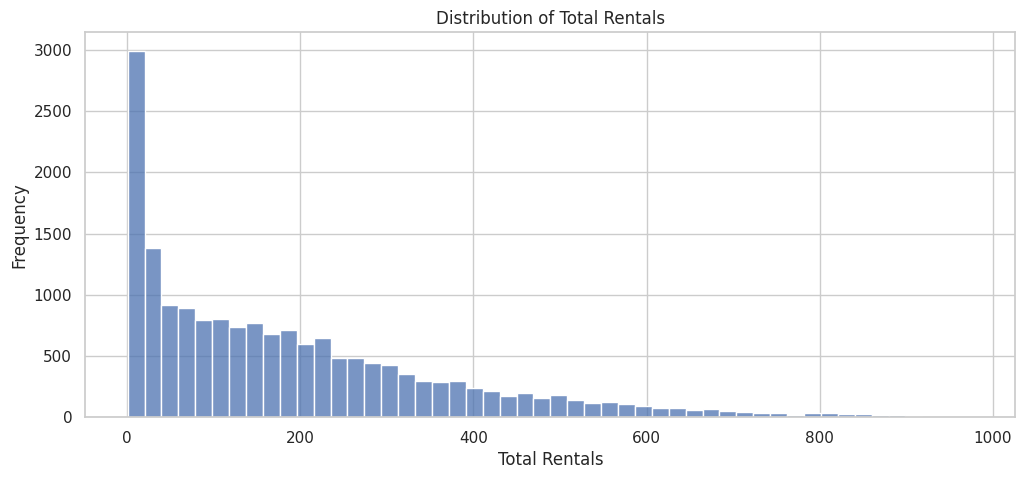

In [18]:
plt.figure(figsize=(12, 5))

sns.histplot(
    df["total_rentals"],
    bins=50,
)

plt.title("Distribution of Total Rentals")
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")

plt.show()

#### Observations

* The distribution of `total_rentals` is positively skewed, with a large concentration of observations at lower rental counts and a long tail extending toward higher demand levels.

* Lower-demand hours occur more frequently than high-demand hours. As rental counts increase, the number of observations decreases steadily.

* The distribution does not appear to contain extreme isolated outliers. Instead, demand gradually tapers off across the higher rental ranges.

* Rental demand varies substantially throughout the dataset, ranging from very low-demand periods to peak hours with nearly 1,000 rentals.

* The observed skewness suggests that simple average-based predictions may not fully capture high-demand periods, making this an important consideration during model evaluation.



### Section Takeaways

The target variable is strongly right-skewed, with low-demand and zero-demand periods occurring much more frequently than high-rental observations.

At the same time, rental demand shows clear temporal structure, including long-term growth trends, recurring seasonal patterns, and substantial short-term fluctuations throughout the dataset timeline.

These findings suggest that temporal, seasonal, and weather-related features will likely play an important role in later machine learning models for bike rental forecasting.

---

## Temporal Target Pattern Analysis

This section explores how bike rental demand changes across different temporal dimensions.

The goal is to identify recurring behavioral patterns, seasonality, and time-dependent demand fluctuations that may later help machine learning models learn rental dynamics more effectively.

### 5.1 Rentals over Time

Rental demand is analyzed over time to better understand long-term trends, seasonality, and fluctuations in bike rental activity.


In [19]:
df["date"] = pd.to_datetime(df["datetime_hour"]).dt.date

daily_rentals = df.groupby("date")["total_rentals"].sum().reset_index()

daily_rentals["date"] = pd.to_datetime(daily_rentals["date"])

daily_rentals.head()

,date,total_rentals
0,2011-01-01,985
1,2011-01-02,801
2,2011-01-03,1349
3,2011-01-04,1562
4,2011-01-05,1600


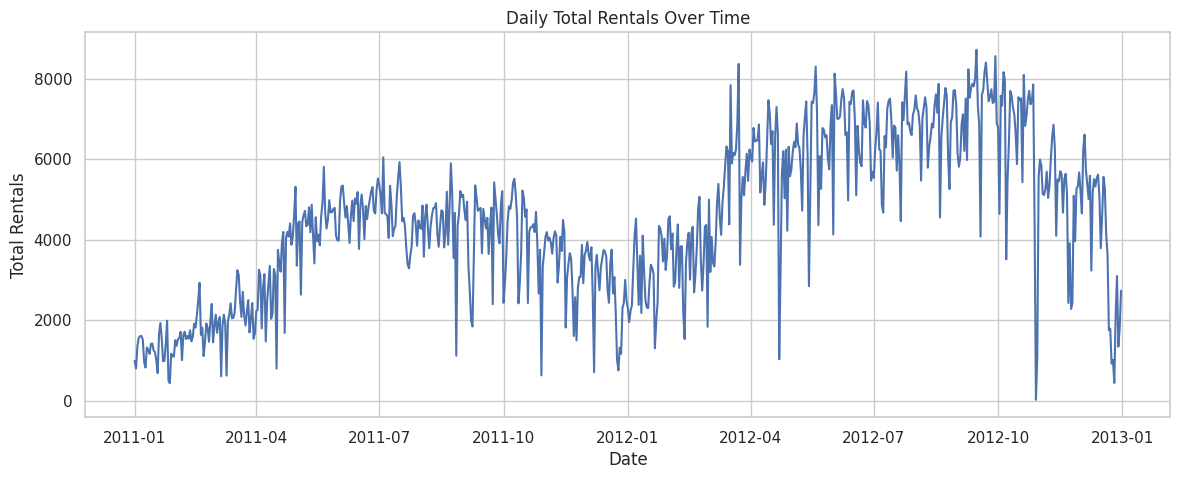

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_rentals["date"],
    daily_rentals["total_rentals"],
)

plt.title("Daily Total Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Total Rentals")

plt.show()

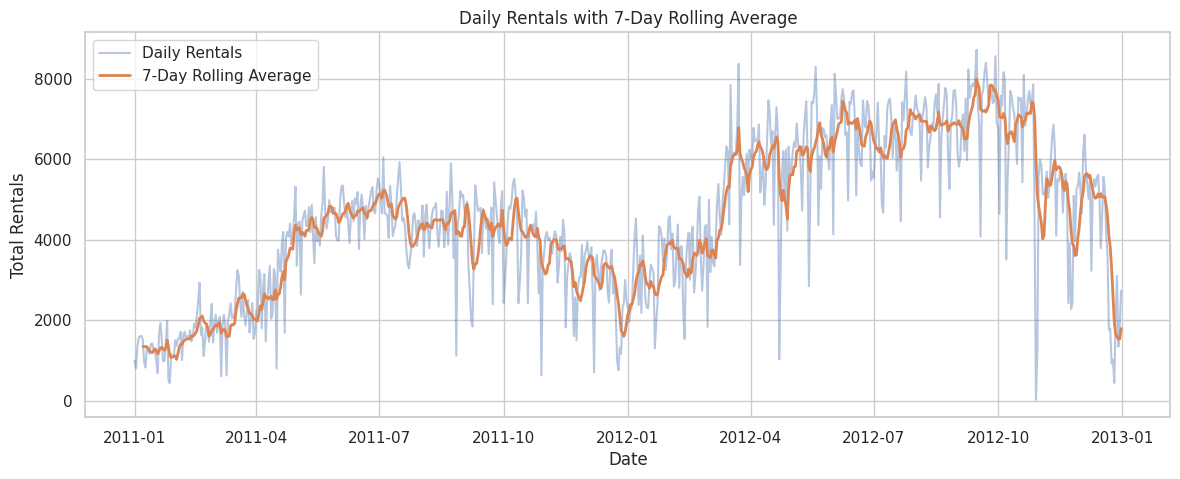

In [21]:
daily_rentals["rolling_mean_7d"] = daily_rentals["total_rentals"].rolling(window=7).mean()

plt.figure(figsize=(14, 5))

plt.plot(
    daily_rentals["date"],
    daily_rentals["total_rentals"],
    alpha=0.4,
    label="Daily Rentals",
)

plt.plot(
    daily_rentals["date"],
    daily_rentals["rolling_mean_7d"],
    linewidth=2,
    label="7-Day Rolling Average",
)

plt.title("Daily Rentals with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Total Rentals")

plt.legend()

plt.show()

#### Observations

* Rental demand shows a clear long-term upward trend across the two-year period, indicating increasing bike rental activity over time.

* Strong seasonal behavior is visible throughout the dataset, with higher rental demand during warmer periods and lower activity during winter months.

* The rolling average smooths short-term fluctuations and highlights recurring demand cycles across both years.

* Daily rental activity still exhibits substantial short-term variability around the rolling trend, suggesting that external factors such as weather conditions, weekdays, holidays, or operational effects may strongly influence rental behavior.

* Several sharp temporary drops in rental activity are visible throughout the timeline and may correspond to holidays, extreme weather conditions, or missing operational observations.


### 5.2 Rentals by Hour

Hourly rental demand is analyzed to identify recurring daily usage patterns and potential peak demand periods throughout the day.


In [22]:
hourly_demand = df.groupby("hour")["total_rentals"].mean().reset_index()

hourly_demand.head(5)

,hour,total_rentals
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941


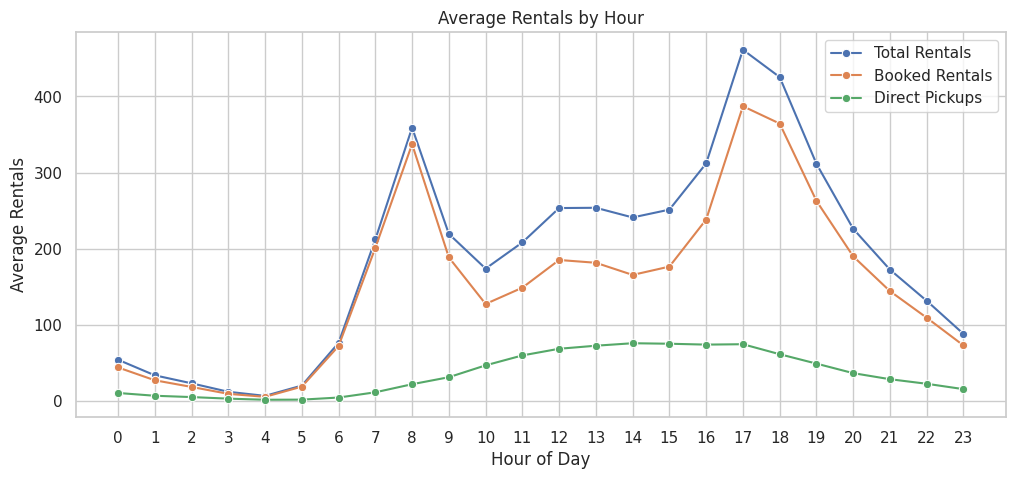

In [23]:
hourly_demand = (
    df.groupby("hour")[["total_rentals", "booked_rentals", "direct_pickups"]].mean().reset_index()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_demand,
    x="hour",
    y="total_rentals",
    marker="o",
    label="Total Rentals",
)

sns.lineplot(
    data=hourly_demand,
    x="hour",
    y="booked_rentals",
    marker="o",
    label="Booked Rentals",
)

sns.lineplot(
    data=hourly_demand,
    x="hour",
    y="direct_pickups",
    marker="o",
    label="Direct Pickups",
)

plt.title("Average Rentals by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")

plt.xticks(range(24))

plt.legend()

plt.show()

#### Observations

* Rental demand exhibits a clear bimodal pattern, with pronounced peaks during the morning and evening hours. This suggests that bike usage is strongly influenced by daily commuting behavior.

* The morning peak occurs around 08:00, while the highest demand is observed around 17:00. The evening peak is noticeably larger than the morning peak across all rental types.

* Booked rentals account for the majority of total demand throughout the day and largely drive the overall demand pattern.

* Direct pickups follow a different trend than booked rentals. While booked rentals show sharp commuting peaks, direct pickups increase more gradually throughout the day and remain relatively stable between late morning and early evening.

* The contribution of direct pickups is proportionally highest during the afternoon hours, suggesting that spontaneous rentals are more common during leisure and daytime activities than during commuting periods.

* Demand is lowest during the early morning hours between 03:00 and 05:00, after which rental activity increases rapidly as the morning commute begins.

* The distinct hourly demand patterns indicate that the `hour` feature is likely to be one of the most important predictors for forecasting rental demand.

* The differing temporal behavior of booked rentals and direct pickups suggests that modeling these demand sources separately may be a worthwhile experiment in later stages of the project.


### 5.3 Rentals by Weekday

Rental demand is analyzed across weekdays to better understand weekly usage behavior and potential differences between workdays and weekends.



In [24]:
weekday_demand = df.groupby("weekday")["total_rentals"].mean().reset_index()

weekday_demand.head(7)

,weekday,total_rentals
0,0,183.744655
1,1,191.238891
2,2,191.130505
3,3,196.436665
4,4,196.135907
5,5,190.209793
6,6,177.468825


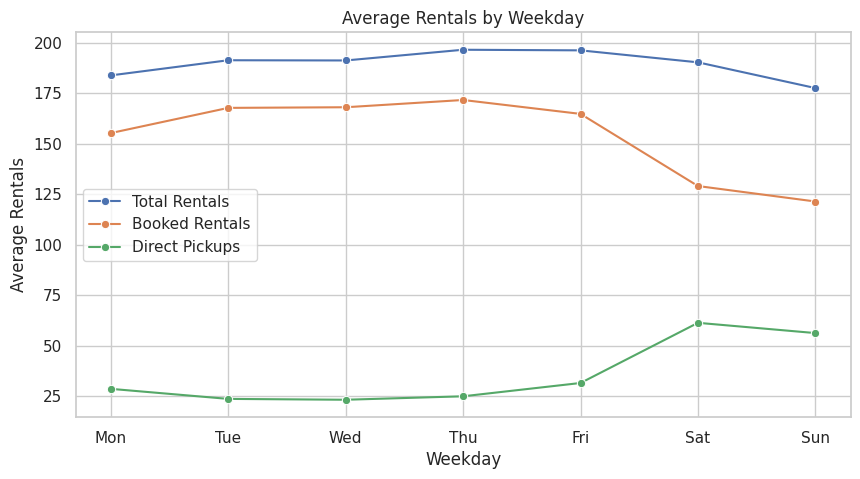

In [25]:
weekday_demand = (
    df.groupby("weekday")[["total_rentals", "booked_rentals", "direct_pickups"]]
    .mean()
    .reset_index()
)

weekday_labels = [
    "Mon",
    "Tue",
    "Wed",
    "Thu",
    "Fri",
    "Sat",
    "Sun",
]

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=weekday_demand,
    x="weekday",
    y="total_rentals",
    marker="o",
    label="Total Rentals",
)

sns.lineplot(
    data=weekday_demand,
    x="weekday",
    y="booked_rentals",
    marker="o",
    label="Booked Rentals",
)

sns.lineplot(
    data=weekday_demand,
    x="weekday",
    y="direct_pickups",
    marker="o",
    label="Direct Pickups",
)

plt.title("Average Rentals by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Rentals")

plt.xticks(
    ticks=range(7),
    labels=weekday_labels,
)

plt.legend()

plt.show()

#### Observations

* Total rental demand remains relatively stable throughout the week, with slightly higher demand on weekdays than on weekends.

* Booked rentals are highest during the workweek and decline noticeably on Saturdays and Sundays, suggesting that many bookings are associated with commuting or regular weekday travel patterns.

* Direct pickups exhibit the opposite behavior, increasing substantially on weekends and reaching their highest levels on Saturday.

* The contrasting weekday patterns of booked rentals and direct pickups indicate that the two rental types may be influenced by different user behaviors and trip purposes.

* The observed weekday effects suggest that the `weekday` feature is likely to provide useful predictive information for rental demand forecasting.


### 5.4 Holiday Effects

Rental demand is analyzed for holidays and non-holidays to better understand how special calendar events influence bike rental activity.



In [26]:
holiday_demand = df.groupby("is_holiday")["total_rentals"].mean().reset_index()

holiday_demand["is_holiday"] = holiday_demand["is_holiday"].map(
    {
        False: "Non-Holiday",
        True: "Holiday",
    }
)

holiday_demand

,is_holiday,total_rentals
0,Non-Holiday,190.42858
1,Holiday,156.87000


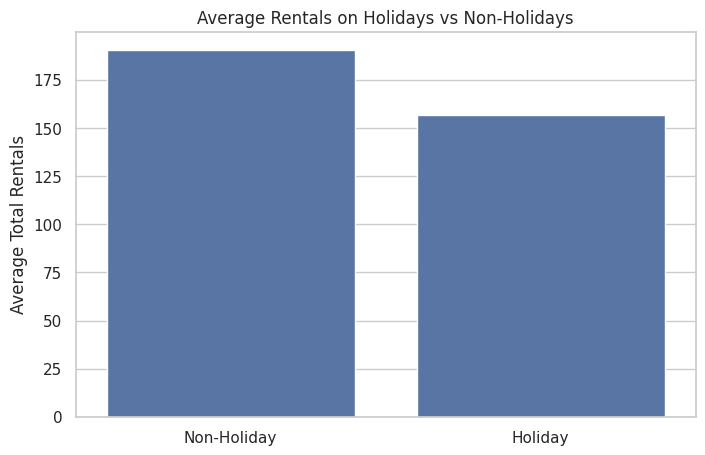

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=holiday_demand,
    x="is_holiday",
    y="total_rentals",
)

plt.title("Average Rentals on Holidays vs Non-Holidays")
plt.xlabel("")
plt.ylabel("Average Total Rentals")

plt.show()

#### Observations

* Average rental demand is lower on holidays compared to non-holidays, indicating that holidays influence regular rental behavior within the dataset.

* The reduced holiday demand further supports the assumption that a substantial portion of bike rentals may be connected to regular commuting activity.


### Section Takeaways

The temporal analysis revealed clear and recurring demand patterns across multiple time dimensions. Rental activity follows pronounced daily cycles, with strong morning and evening peaks, and exhibits distinct differences between booked rentals and direct pickups.

Demand remains relatively stable throughout the workweek, while weekends show a shift from booked rentals toward direct pickups, suggesting different user behaviors and trip purposes.

The long-term time series further revealed strong seasonality and an overall upward demand trend. Together, these findings indicate that temporal features are likely to be among the most important predictors for bike rental forecasting and suggest that historical demand information may provide additional predictive value.

---


## 6. Weather Analysis

Weather conditions are expected to influence bike rental demand and may provide important predictive signals for later forecasting models.

This section explores the relationship between rental activity and several weather-related features, including temperature, weather conditions, humidity, and windspeed. The goal is to understand how weather affects rental behavior and identify potentially useful features for machine learning.


### 6.1 Temperature vs Rentals

Temperature is often one of the strongest drivers of bike rental demand. This section investigates the relationship between temperature and rental activity using both correlation analysis and aggregated daily demand patterns.

Analyzing daily average temperature helps reduce the influence of hourly commuting behavior and provides a clearer view of the overall relationship between weather and rental demand.


In [28]:
df[
    [
        "temperature_c",
        "perceived_temperature_c",
        "total_rentals",
    ]
].corr()

,temperature_c,perceived_temperature_c,total_rentals
temperature_c,1.000000,0.992164,0.404758
perceived_temperature_c,0.992164,1.000000,0.403413
total_rentals,0.404758,0.403413,1.000000


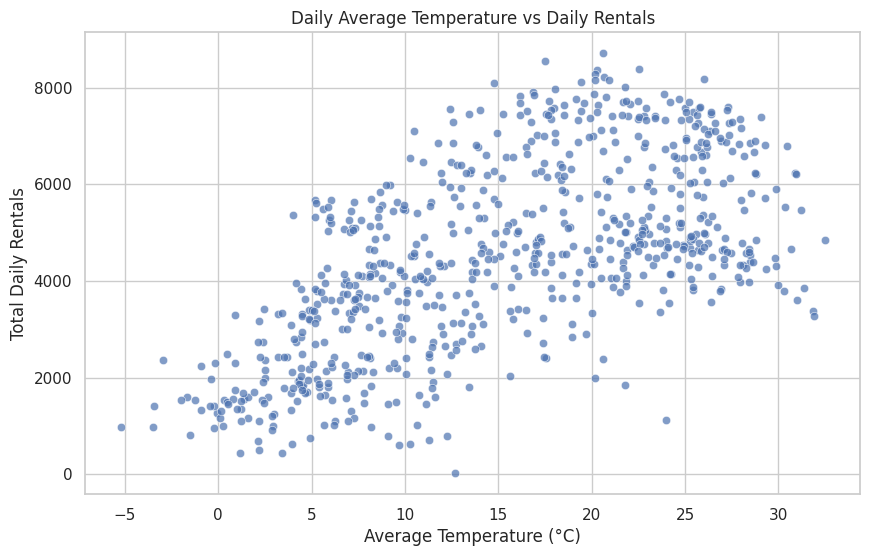

In [29]:
daily_weather = (
    df.groupby("date")
    .agg(
        avg_temperature=("temperature_c", "mean"),
        total_rentals=("total_rentals", "sum"),
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=daily_weather,
    x="avg_temperature",
    y="total_rentals",
    alpha=0.7,
)

plt.title("Daily Average Temperature vs Daily Rentals")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Total Daily Rentals")

plt.show()

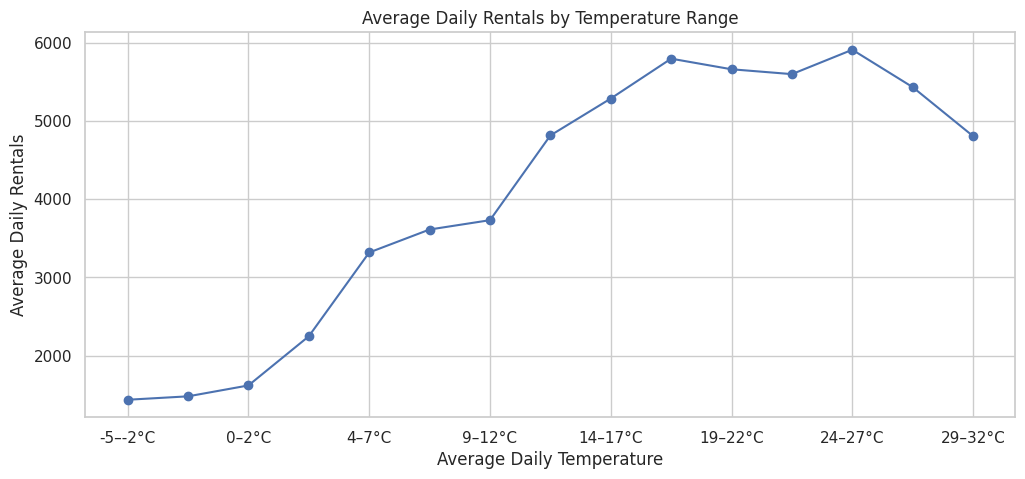

In [30]:
temperature_bins = daily_weather.groupby(
    pd.cut(
        daily_weather["avg_temperature"],
        bins=15,
    ),
    observed=False,
)["total_rentals"].mean()

temperature_bins.index = [
    f"{int(interval.left)}–{int(interval.right)}°C" for interval in temperature_bins.index
]

plt.figure(figsize=(12, 5))

temperature_bins.plot(marker="o")

plt.title("Average Daily Rentals by Temperature Range")
plt.xlabel("Average Daily Temperature")
plt.ylabel("Average Daily Rentals")


plt.show()

#### Observations

* Temperature shows a moderate positive correlation with rental demand, indicating that warmer conditions are generally associated with higher bike rental activity.

* The daily temperature scatterplot reveals a clear upward trend, although substantial variation remains at similar temperature levels, suggesting that additional factors such as time, weather conditions, and holidays also influence demand.

* Average daily rentals increase steadily as temperatures rise from winter conditions to moderate temperatures.

* Rental demand appears to peak around temperatures between 20°C and 27°C, after which demand begins to level off or slightly decline during the hottest periods.

* The very high correlation between actual and perceived temperature indicates that both features contain largely overlapping information and may provide similar predictive value for later machine learning models.


### 6.2 Weather Conditions vs Rentals

In addition to temperature, general weather conditions may influence rental behavior. This section compares rental demand across different weather categories to understand how favorable and unfavorable weather affects bike usage.


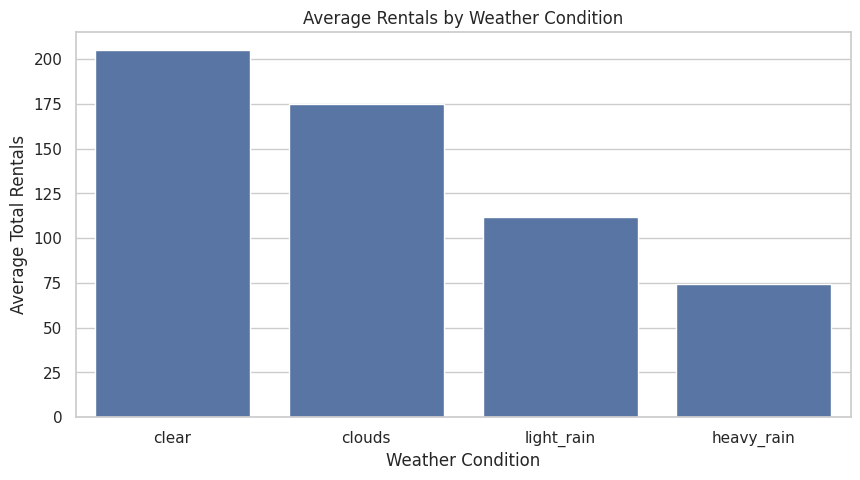

In [31]:
condition_demand = (
    df.groupby("conditions")["total_rentals"].mean().sort_values(ascending=False).reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=condition_demand,
    x="conditions",
    y="total_rentals",
)

plt.title("Average Rentals by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Total Rentals")

plt.show()

#### Observations

* Rental demand decreases consistently as weather conditions worsen.

* Clear weather is associated with the highest average rental activity, while heavy rain corresponds to the lowest demand levels.

* The difference between clear weather and heavy rain is substantial, suggesting that weather conditions have a meaningful impact on bike rental behavior.


### 6.3 Humidity vs Rentals

Humidity may influence bike rental demand by affecting overall comfort during outdoor travel. This section explores the relationship between humidity and rental activity to assess whether humidity provides useful predictive information for later forecasting models.



In [32]:
df[
    [
        "humidity",
        "total_rentals",
    ]
].corr()

,humidity,total_rentals
humidity,1.000000,-0.330103
total_rentals,-0.330103,1.000000


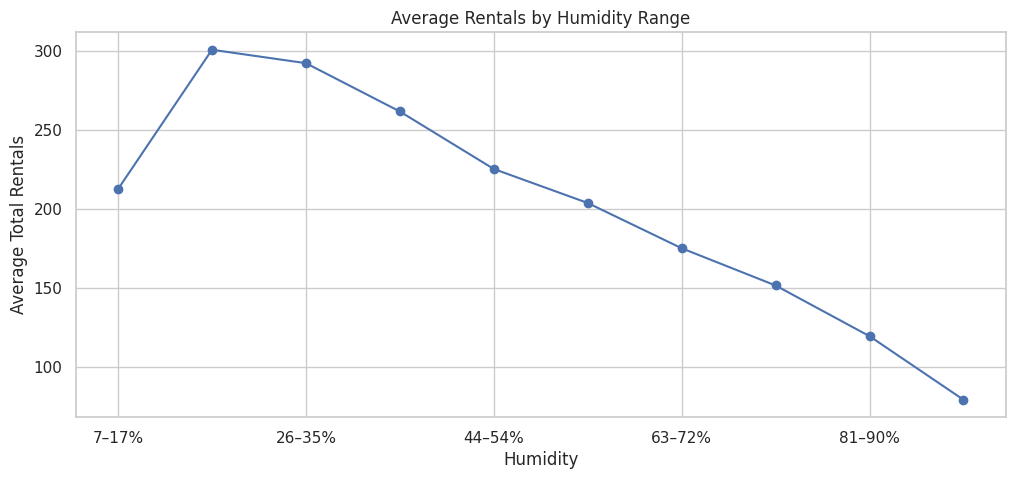

In [33]:
humidity_bins = df.groupby(
    pd.cut(
        df["humidity"],
        bins=10,
    ),
    observed=False,
)["total_rentals"].mean()

humidity_bins.index = [
    f"{int(interval.left)}–{int(interval.right)}%" for interval in humidity_bins.index
]

plt.figure(figsize=(12, 5))

humidity_bins.plot(
    marker="o",
)

plt.title("Average Rentals by Humidity Range")
plt.xlabel("Humidity")
plt.ylabel("Average Total Rentals")

plt.show()

#### Observations

* Humidity shows a moderate negative correlation with rental demand, indicating that higher humidity levels are generally associated with lower bike rental activity.

* Average rental demand is highest at moderate humidity levels and decreases steadily as humidity increases.

* Very humid conditions (above roughly 80%) are associated with substantially lower rental demand, suggesting that less comfortable weather conditions discourage bike usage.

* Overall, humidity appears to contain useful predictive information, although its relationship with rental demand is weaker than the temperature effect observed earlier.



### 6.4 Windspeed vs Rentals

Strong winds may affect the comfort and practicality of bike travel and could therefore influence rental demand. This section explores the relationship between windspeed and bike rental activity to assess whether windspeed provides useful predictive information for later forecasting models.



In [34]:
df[
    [
        "windspeed_kmh",
        "total_rentals",
    ]
].corr()

,windspeed_kmh,total_rentals
windspeed_kmh,1.000000,0.093239
total_rentals,0.093239,1.000000


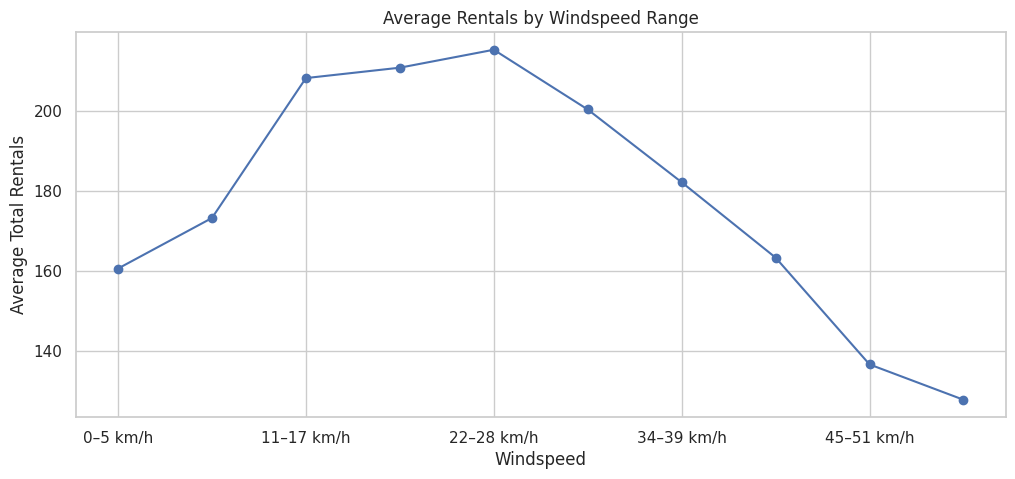

In [35]:
windspeed_bins = df.groupby(
    pd.cut(
        df["windspeed_kmh"],
        bins=10,
    ),
    observed=False,
)["total_rentals"].mean()


windspeed_bins.index = [
    f"{int(interval.left)}–{int(interval.right)} km/h" for interval in windspeed_bins.index
]

plt.figure(figsize=(12, 5))

windspeed_bins.plot(
    marker="o",
)

plt.title("Average Rentals by Windspeed Range")
plt.xlabel("Windspeed")
plt.ylabel("Average Total Rentals")

plt.show()

#### Observations

* Windspeed shows only a very weak positive correlation with rental demand, suggesting a limited direct relationship between the two variables.

* Average rental demand increases from low to moderate windspeed levels and reaches its highest values around 20–30 km/h.

* At higher windspeed levels, rental demand gradually declines, indicating that stronger winds may discourage bike usage.

* The relationship appears noticeably weaker than the effects observed for temperature, weather conditions, and humidity.

* Overall, windspeed may still provide some predictive value, but it is likely to be a less influential feature than the other weather variables analyzed in this section.


### Section Takeaways

Weather features show clear relationships with bike rental demand and are likely to provide valuable predictive information for forecasting models.

Temperature appears to be the strongest weather-related predictor, while weather conditions and humidity also demonstrate meaningful effects on rental activity. In contrast, windspeed exhibits only a relatively weak relationship with demand.

The analysis also suggests that actual and perceived temperature contain highly similar information and may be redundant for later modeling.

---


## 7. Correlation and Feature Relationships

This section examines relationships between numerical features and identifies potential dependencies that may influence later machine learning models.

The goal is to identify promising predictor variables, detect highly correlated features, and assess potential multicollinearity issues before model development.


### 7.1 Correlation Analysis

A correlation heatmap provides an overview of the linear relationships between numerical features in the dataset.


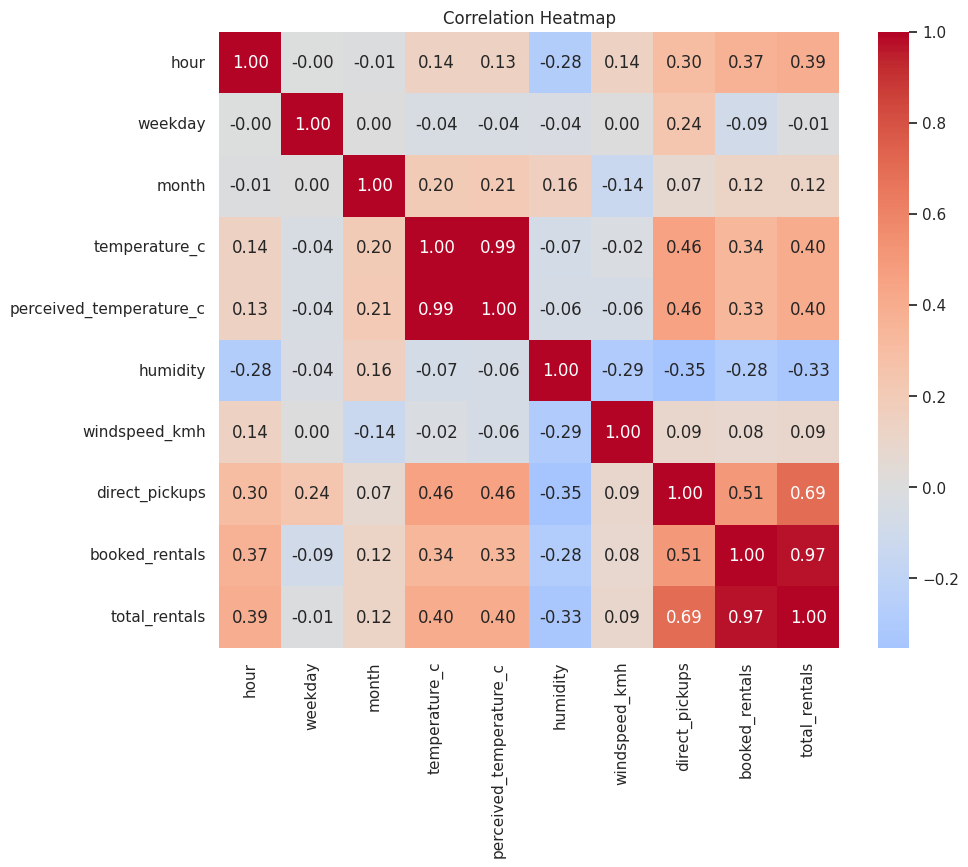

In [36]:
numerical_features = [
    "hour",
    "weekday",
    "month",
    "temperature_c",
    "perceived_temperature_c",
    "humidity",
    "windspeed_kmh",
    "direct_pickups",
    "booked_rentals",
    "total_rentals",
]

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title("Correlation Heatmap")

plt.show()

In [37]:
target_correlations = (
    correlation_matrix["total_rentals"]
    .drop("total_rentals")
    .sort_values(
        key=abs,
        ascending=False,
    )
)

target_correlations

booked_rentals             0.972151
direct_pickups             0.694564
temperature_c              0.404758
perceived_temperature_c    0.403413
hour                       0.394071
humidity                  -0.330103
month                      0.120638
windspeed_kmh              0.093239
weekday                   -0.006338
Name: total_rentals, dtype: float64

#### Observations

* `booked_rentals` and `direct_pickups` exhibit the strongest correlations with the target variable, which is expected since both variables directly contribute to `total_rentals`.

* Among the external predictor candidates, temperature and perceived temperature show the strongest positive relationships with rental demand.

* Humidity exhibits the strongest negative correlation with the target variable, supporting the earlier observation that rental demand tends to decrease under more humid conditions.

* The hour of day also shows a meaningful positive relationship with rental activity, reflecting the strong daily demand patterns identified in the temporal analysis.

* Month and windspeed show relatively weak correlations, while weekday exhibits almost no linear relationship with rental demand.


### 7.2 Multicollinearity and Modeling Considerations

The correlation analysis revealed several strong relationships between features. While some of these relationships may improve predictive performance, others could introduce redundancy or lead to target leakage during model training.

Understanding these dependencies is important when selecting features for future machine learning models.


In [38]:
df[
    [
        "temperature_c",
        "perceived_temperature_c",
    ]
].corr()

,temperature_c,perceived_temperature_c
temperature_c,1.000000,0.992164
perceived_temperature_c,0.992164,1.000000


In [39]:
df[
    [
        "booked_rentals",
        "direct_pickups",
        "total_rentals",
    ]
].corr()

,booked_rentals,direct_pickups,total_rentals
booked_rentals,1.000000,0.506618,0.972151
direct_pickups,0.506618,1.000000,0.694564
total_rentals,0.972151,0.694564,1.000000


#### Observations

* Actual and perceived temperature are almost perfectly correlated, indicating that both features contain largely overlapping information.

* Including both temperature features may provide little additional predictive value and could introduce unnecessary redundancy into some models.

* `booked_rentals` and `direct_pickups` are strongly correlated with `total_rentals` because they are direct components of the target variable.

* These operational variables would not be available when forecasting future demand and would therefore introduce target leakage if used as predictors.



### Section Takeaways

The correlation analysis confirms that temperature, humidity, weather conditions, and temporal features are promising predictors of rental demand.

The analysis also identified two important modeling considerations: the strong redundancy between actual and perceived temperature, and the presence of target leakage through the operational rental variables. Both issues should be addressed during feature selection and model development.

---

## 8. Initial Modeling Considerations

The previous analyses identified several patterns and relationships that may influence future machine learning models. This section summarizes promising candidate features, highlights potential modeling risks, and discusses an appropriate validation strategy for demand forecasting.


### 8.1 Candidate Features

Based on the exploratory analysis, several feature groups appear promising for predicting bike rental demand.

Potential candidate features include:

* Temporal features (`hour`, `weekday`, `month`, `is_weekend`, `is_holiday`)
* Weather features (`temperature_c`, `humidity`, `windspeed_kmh`, `conditions`)
* Encoded cyclical features for hourly and weekly patterns
* Historical demand features such as lagged rentals and rolling averages

The strong temporal patterns and weather relationships observed throughout the analysis suggest that these feature groups are likely to contribute meaningful predictive information.


### 8.2 Potential Risks

Several considerations should be addressed before model development.

* `booked_rentals` and `direct_pickups` are direct components of the target variable and would introduce target leakage if used as predictors.
* `temperature_c` and `perceived_temperature_c` contain highly overlapping information and may introduce unnecessary redundancy.
* The `conditions` feature is categorical and will require appropriate encoding before model training.
* Missing time periods in the historical data should be considered when creating lag-based features.


### 8.3 Validation Strategy

For time-dependent forecasting problems, a random train-test split may lead to overly optimistic performance estimates because future observations can influence the training process.

A time-based split better reflects real-world forecasting scenarios by ensuring that models are trained on historical data and evaluated on future periods.

Therefore, a chronological train-test split is likely to provide a more realistic assessment of future model performance.

---

## 9. Conclusions

This exploratory data analysis examined the structure, quality, and predictive characteristics of the prepared bike rental dataset.

### Key Findings

* Bike rental demand exhibits strong temporal patterns, including pronounced daily cycles, seasonal trends, and holiday-related effects.
* Weather conditions have a meaningful influence on rental activity, with temperature showing the strongest relationship among the weather features.
* Humidity and weather conditions also appear to contain useful predictive information, while windspeed exhibits a comparatively weaker relationship with demand.
* Several potential modeling issues were identified, including target leakage through operational rental features

### Data Quality Findings

* The preprocessing pipeline produced a largely complete and consistent modeling dataset.
* A small number of missing time periods were identified due to unavailable operational and weather observations.

### Promising Feature Candidates

* Temporal features (`hour`, `weekday`, `month`, `is_weekend`, `is_holiday`)
* Weather features (`temperature_c`, `humidity`, `conditions`)
* Cyclical time encodings
* Historical demand features such as lagged rentals and rolling statistics

### Next Steps

The findings from this analysis will guide the feature engineering and model development stages. Future work will focus on creating forecasting-oriented features, selecting appropriate validation strategies, and building regression models for bike rental demand prediction.
